In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import pickle
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

In [3]:
macro_map = {
    # POLÍTICA
    2: "Política Americana",
    27: "Política Americana",
    28: "Política Americana",
    35: "Política Americana",
    38: "Política Americana",
    53: "Política Americana",
    57: "Política Americana",

    # POLÍTICA EXTERIOR
    5: "Política Exterior",
    18: "Política Exterior",
    20: "Política Exterior",
    22: "Política Exterior",
    26: "Política Exterior",
    33: "Política Exterior",
    37: "Política Exterior",
    39: "Política Exterior",
    47: "Política Exterior",
    48: "Política Exterior",
    56: "Política Exterior",
    58: "Política Exterior",
    23: "Política Exterior",

    # CRIME, SEGURANÇA E JUSTIÇA
    24: "Crime, Segurança e Justiça",
    34: "Crime, Segurança e Justiça",
    51: "Crime, Segurança e Justiça",
    59: "Crime, Segurança e Justiça",
    31: "Crime, Segurança e Justiça",
    13: "Crime, Segurança e Justiça",

    # RELIGIÃO 
    0: "Religião",
    12: "Religião",

    # TECNOLOGIA
    60: "Tecnologia",
    43: "Tecnologia",
    45: "Tecnologia",

    # SAÚDE
    8: "Saúde",
    15: "Saúde",
    
    # MEIO AMBIENTE
    10: "Meio Ambiente",
    36: "Meio Ambiente",
    42: "Meio Ambiente",
    44: "Meio Ambiente",
    52: "Meio Ambiente",
    19: "Meio Ambiente",

    # ENTRETENIMENTO E CULTURA POP
    1: "Entretenimento e Cultura Pop",
    7: "Entretenimento e Cultura Pop",
    11: "Entretenimento e Cultura Pop",
    14: "Entretenimento e Cultura Pop",
    30: "Entretenimento e Cultura Pop",
    40: "Entretenimento e Cultura Pop",
    25: "Entretenimento e Cultura Pop",
    41: "Entretenimento e Cultura Pop",

    # ESTILO DE VIDA E HOBBIES
    16: "Estilo de Vida e Hobbies",
    17: "Estilo de Vida e Hobbies",
    21: "Estilo de Vida e Hobbies",
    54: "Estilo de Vida e Hobbies",
    9: "Estilo de Vida e Hobbies",
    29: "Estilo de Vida e Hobbies",

    # GUERRA
    4: "Guerra",
    6: "Guerra",
    32: "Guerra",
    46: "Guerra",
    50: "Guerra",

    # OUTROS
    -1: "Outros",
    3: "Outros",
    49: "Outros",
    55: "Outros"
}


In [4]:
df = pd.read_csv("data/youtube_telegram_cross.csv")
df_train = pd.read_csv("sample_yt_te_cross_with_topics.csv")

print(len(df))
print(len(df_train))

673587
67357


In [5]:
df_train["macro_topic"] = df_train["topic"].map(macro_map)
display(df_train)

,Unnamed: 0,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,topic,interest,macro_topic
0,0,QKXr7N9c6Yo,roman islamic antichrist sonia azam explore bi...,Armageddon News,2021-10-11T16:36:04Z,2249.0,107.0,75.0,"[{'id': 28786, 'folder': 'channel_2165208912',...",0.003288,0.000109,0.000247,0.000162,0.000228,0.000284,0,1,Religião
1,1,qRFdVxvlXRY,kamala interview prove weak hope prove point w...,Real America's Voice,2024-10-08T14:57:04Z,498.0,89.0,10.0,"[{'id': 33565, 'folder': 'channel_1937328148',...",0.000926,0.000104,0.000178,0.000124,0.000195,0.000136,2,1,Política Americana
2,2,Y8KzbOkN_TM,money ttaakaa syllabus baire epbong welcome ep...,Your Bong Guy,2024-11-07T12:23:25Z,1198216.0,103644.0,5457.0,"[{'id': 3555926, 'folder': 'channel_1279841660...",0.005160,0.000092,0.000415,0.000128,0.000365,0.000166,-1,0,Outros
3,3,B5yS8olxa80,save israel jeremy gimpel live update frontlin...,thelandofisrael,2023-11-28T16:48:23Z,11835.0,1668.0,212.0,"[{'id': 37539, 'folder': 'channel_1592308283',...",0.002251,0.000098,0.000225,0.000128,0.000196,0.000200,4,1,Guerra
4,4,JnvOJN5yF8s,kingdom planet official trailer cinemas yang b...,20th Century Studios Indonesia,2024-02-12T01:24:59Z,211122.0,1928.0,374.0,"[{'id': 422797, 'folder': 'channel_1905119305'...",0.001937,0.000101,0.000238,0.000136,0.000227,0.000176,-1,0,Outros
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67352,67352,-yqaSl75CWg,donald trump black conservative federation hon...,MAGNO NEWS,2024-02-24T03:36:18Z,132923.0,4173.0,694.0,"[{'id': 37202, 'folder': 'channel_1511714855',...",0.010595,0.000125,0.000877,0.000230,0.000510,0.000335,2,1,Política Americana
67353,67353,B-9TmfJKIDw,revenge vseasy bgmi revange vvsvclutch vsclutc...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2024-01-09T21:03:28Z,76.0,6.0,0.0,"[{'id': 202730, 'folder': 'channel_1215588509'...",0.586373,0.004986,0.230517,0.005853,0.080524,0.014184,-1,0,Outros
67354,67354,5UfW-xNR7QE,stop celebrate year bible israel gaza jesus pa...,Aries Entertainment Podcast,2024-02-16T14:44:17Z,946556.0,NaN,3684.0,"[{'id': 561053, 'folder': 'channel_1905119305'...",0.126986,0.000889,0.005506,0.002209,0.003185,0.019822,4,1,Guerra
67355,67355,LwAVckmcj9k,know gaza bible israel jesus palestine youtube...,Aries Entertainment Podcast,2024-03-02T13:50:44Z,4215776.0,NaN,5746.0,"[{'id': 132237, 'folder': 'channel_1457622198'...",0.119244,0.000962,0.007461,0.002136,0.003629,0.018202,4,1,Guerra


In [6]:
# Corrige alinhamento de índices
df_embeddings = df[['video_id']].copy()
df_embeddings['embedding_index'] = np.arange(len(df))
df_train_merged = df_train.merge(df_embeddings, on='video_id', how='left')

missing = df_train_merged['embedding_index'].isna().sum()
print(f"Linhas sem embedding correspondente: {missing}")

Linhas sem embedding correspondente: 0


In [7]:
train_idx = df_train_merged['embedding_index'].dropna().astype(int).values
y = df_train_merged["macro_topic"]

embeddings = np.load("classification_models/embeddings.npy")
embeddings_reduced = np.load("classification_models/embeddings_reduced.npy")

X = embeddings[train_idx]
X_reduced = embeddings_reduced[train_idx]

In [8]:
def run_model(name, model, param_grid, X, y, cv_splits=5):
    print(f"\n Rodando modelo: {name}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    strat_kfold = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    clf = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=strat_kfold,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    clf.fit(X_scaled, y)
    best_model = clf.best_estimator_
    print(f"Melhores hiperparâmetros encontrados: {clf.best_params_}")

    print(f"=== {name} ===\n")
    print(f"Melhores parâmetros: {clf.best_params_}\n\n")

    reports = []
    for fold, (train_idx, test_idx) in enumerate(strat_kfold.split(X_scaled, y), 1):
        y_pred = best_model.fit(X_scaled[train_idx], y[train_idx]).predict(X_scaled[test_idx])
        report = classification_report(y[test_idx], y_pred, digits=3, output_dict=True)
        reports.append(report)

        print(f"\n--- Fold {fold} ---\n")
        print(classification_report(y[test_idx], y_pred, digits=3))
        print("\n")

    avg_f1_macro = np.mean([r['macro avg']['f1-score'] for r in reports])
    std_f1_macro = np.std([r['macro avg']['f1-score'] for r in reports])
    print(f"\nMédia F1 Macro: {avg_f1_macro:.3f} ± {std_f1_macro:.3f}\n")

    print(f"✅ Finalizado: {name} | Média F1 Macro: {avg_f1_macro:.3f}")
    return best_model

In [9]:
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, None],
    "min_samples_split": [2, 5],
    'class_weight': [None, 'balanced']
}
     

best_model = run_model(
    name="Random Forest",
    model=RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=params,
    X=X_reduced,
    y=y,
    cv_splits=5
)



 Rodando modelo: Random Forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits


Melhores hiperparâmetros encontrados: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
=== Random Forest ===

Melhores parâmetros: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}



--- Fold 1 ---

                              precision    recall  f1-score   support

  Crime, Segurança e Justiça      0.574     0.576     0.575       276
Entretenimento e Cultura Pop      0.777     0.786     0.782      2291
    Estilo de Vida e Hobbies      0.705     0.707     0.706       403
                      Guerra      0.820     0.842     0.831      1043
               Meio Ambiente      0.707     0.732     0.719       317
                      Outros      0.740     0.713     0.726      4825
          Política Americana      0.791     0.803     0.797      1015
           Política Exterior      0.789     0.775     0.782       832
                    Religião      0.813     0.861     0.836      2154
            

In [10]:
df_train_merged[df_train_merged["macro_topic"].isna()][["video_id", "topic"]]


,video_id,topic


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_reduced)

In [12]:
# embeddings reduzidos para TODOS os vídeos
all_embeddings_reduced = embeddings_reduced

# aplica o mesmo scaler usado no treino
all_embeddings_scaled = scaler.transform(all_embeddings_reduced)

pred_all = best_model.predict(all_embeddings_scaled)
prob_all = best_model.predict_proba(all_embeddings_scaled)[:, 1]  


In [13]:
df['macrotopic_pred'] = pred_all
df['macrotopic_prob'] = prob_all

In [14]:
display(df)

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,macrotopic_pred,macrotopic_prob
0,jEKzQV5oajY,travel migrant scrap minute,Joe Marsh,2024-04-10T15:05:37Z,1057.0,152.0,32.0,"[{'id': 1416, 'folder': 'channel_1556142220', ...",0.000659,0.000117,0.000183,0.000114,0.000178,0.000138,Outros,0.000000
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'id': 60799, 'folder': 'channel_1466271872',...",0.295000,0.001137,0.003694,0.012858,0.003023,0.006275,Religião,0.014446
2,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,0.000245,0.000142,0.000204,0.000156,Outros,0.002062
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,"[{'id': 449843, 'folder': 'channel_1571505334'...",0.002710,0.000104,0.000254,0.000185,0.000239,0.000192,Religião,0.010808
4,AKU0RokegSo,angeles rain studio city evacuate mudslide atm...,FOX 11 Los Angeles,2024-02-06T01:45:29Z,60863.0,406.0,152.0,"[{'id': 104116, 'folder': 'channel_1438734111'...",0.001515,0.000100,0.000217,0.000126,0.000203,0.000143,Meio Ambiente,0.031122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673582,ABpufr8inCY,eruption kilauea volcano earthquake activity i...,TheEarthMaster,2024-09-17T19:15:25Z,10563.0,712.0,38.0,"[{'id': 30195, 'folder': 'channel_1177617529',...",0.003324,0.000098,0.000358,0.000123,0.000247,0.000152,Meio Ambiente,0.000000
673583,5VWWCeGrr-w,eslteacher funny kidsvideo play easy makeup le...,Game fanny,2024-05-08T22:00:03Z,2.0,0.0,0.0,"[{'id': 1531863, 'folder': 'channel_1391678616...",0.004620,0.000084,0.000295,0.000108,0.000313,0.000175,Outros,0.123306
673584,RxbPFQp0SHs,unbelievable ending play bgmi bgmi gameplay su...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2023-12-29T23:30:11Z,82.0,4.0,0.0,"[{'id': 197485, 'folder': 'channel_1215588509'...",0.023877,0.000158,0.002297,0.000265,0.001188,0.000347,Outros,0.040848
673585,GEhEUy85PsY,meet balkan,Icariaball,2021-04-22T16:25:46Z,7617763.0,210152.0,14042.0,"[{'id': 7719, 'folder': 'channel_1753496417', ...",0.007485,0.000123,0.000266,0.000247,0.000321,0.000520,Outros,0.013916


In [15]:
df_final = df

In [16]:
import pandas as pd
import ast

# Exemplo: seu df original
# df = pd.read_csv("videos.csv")

# Converte a string para lista de dicts
def parse_occurrences(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df_final['occ_list'] = df_final['occurrences'].apply(parse_occurrences)

# Explode a lista — uma linha por ocorrência
df_exploded = df_final.explode('occ_list', ignore_index=True)

# Extrai a data de cada ocorrência
df_exploded['date'] = df_exploded['occ_list'].apply(lambda x: x.get('date') if isinstance(x, dict) and 'date' in x else None)

# Converte para datetime
df_exploded['date'] = pd.to_datetime(df_exploded['date'], errors='coerce')

display(df_exploded)


,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,macrotopic_pred,macrotopic_prob,occ_list,date
0,jEKzQV5oajY,travel migrant scrap minute,Joe Marsh,2024-04-10T15:05:37Z,1057.0,152.0,32.0,"[{'id': 1416, 'folder': 'channel_1556142220', ...",0.000659,0.000117,0.000183,0.000114,0.000178,0.000138,Outros,0.000000,"{'id': 1416, 'folder': 'channel_1556142220', '...",2024-04-14
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'id': 60799, 'folder': 'channel_1466271872',...",0.295000,0.001137,0.003694,0.012858,0.003023,0.006275,Religião,0.014446,"{'id': 60799, 'folder': 'channel_1466271872', ...",2024-01-06
2,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,0.000245,0.000142,0.000204,0.000156,Outros,0.002062,"{'id': 40486, 'folder': 'channel_1235978663', ...",2024-02-22
3,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,0.000245,0.000142,0.000204,0.000156,Outros,0.002062,"{'id': 17774, 'folder': 'channel_1476013048', ...",2024-02-22
4,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,0.000245,0.000142,0.000204,0.000156,Outros,0.002062,"{'id': 40492, 'folder': 'channel_1235978663', ...",2024-02-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3496886,RxbPFQp0SHs,unbelievable ending play bgmi bgmi gameplay su...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2023-12-29T23:30:11Z,82.0,4.0,0.0,"[{'id': 197485, 'folder': 'channel_1215588509'...",0.023877,0.000158,0.002297,0.000265,0.001188,0.000347,Outros,0.040848,"{'id': 197485, 'folder': 'channel_1215588509',...",2023-12-30
3496887,RxbPFQp0SHs,unbelievable ending play bgmi bgmi gameplay su...,𝐒∆𝐈𝐘𝐀𝐍 • 127K views • 6 hours ago,2023-12-29T23:30:11Z,82.0,4.0,0.0,"[{'id': 197485, 'folder': 'channel_1215588509'...",0.023877,0.000158,0.002297,0.000265,0.001188,0.000347,Outros,0.040848,"{'id': 197791, 'folder': 'channel_1215588509',...",2023-12-30
3496888,GEhEUy85PsY,meet balkan,Icariaball,2021-04-22T16:25:46Z,7617763.0,210152.0,14042.0,"[{'id': 7719, 'folder': 'channel_1753496417', ...",0.007485,0.000123,0.000266,0.000247,0.000321,0.000520,Outros,0.013916,"{'id': 7719, 'folder': 'channel_1753496417', '...",2023-12-26
3496889,fNTfEPLoAik,clark county sheriff arrest felony count clark...,WLKY News Louisville,2023-11-09T09:24:16Z,358.0,5.0,NaN,"[{'id': 86067, 'folder': 'channel_1172210773',...",0.007710,0.000096,0.000594,0.000142,0.000381,0.000157,"Crime, Segurança e Justiça",0.004041,"{'id': 86067, 'folder': 'channel_1172210773', ...",2023-11-09


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_weekly_toxicity_macros(df, title_label):

    # --- Preparação ---
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Criar coluna semanal no formato "YYYY-WW"
    df["week"] = df["date"].dt.to_period("W").astype(str)

    # Cores fixas para os macrotópicos

    macro_colors = {
        "Política Americana":             "#6AF5FF",
        "Política Exterior":              "#76FF7F",
        "Crime, Segurança e Justiça":     "#FF66CC",
        "Meio Ambiente":                  "#522222",
        "Saúde":                          "#14712A",
        "Entretenimento e Cultura Pop":   "#ECF988",
        "Estilo de Vida e Hobbies":       "#DA0000",
        "Religião":                       "#962EAA",
        "Tecnologia":                     "#0000FF",
        "Guerra":                         "#5C5C61",
        "Outros":                         "#FF9900"
    }

    # Agrupar: média de toxicidade por semana + macrotópico
    grouped = (
        df.groupby(["week", "macrotopic_pred"])["toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- Plotagem ---
    sns.set(style="whitegrid")
    plt.figure(figsize=(16, 6))

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week"],
            m_df["toxicity"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333")
        )

    plt.title(f"Evolução Semanal da Toxicidade — {title_label}")
    plt.xlabel("Semana")
    plt.ylabel("Toxicidade Média")
    plt.xticks(rotation=45)
    plt.ylim(0, 0.3)

    handles = [
        Line2D([0], [0], marker="s", linestyle="",
               color=macro_colors[m], markersize=12, label=m)
        for m in macro_categories
    ]

    plt.legend(handles=handles, title="Macrotópico",
               bbox_to_anchor=(1.05, 1), loc="upper left")

    # reduzir número de labels no eixo X
    ax = plt.gca()
    step = 8  # mostra 1 label a cada 8 semanas (ajuste à vontade)
    ax.set_xticks(ax.get_xticks()[::step])

    plt.tight_layout()
    plt.show()


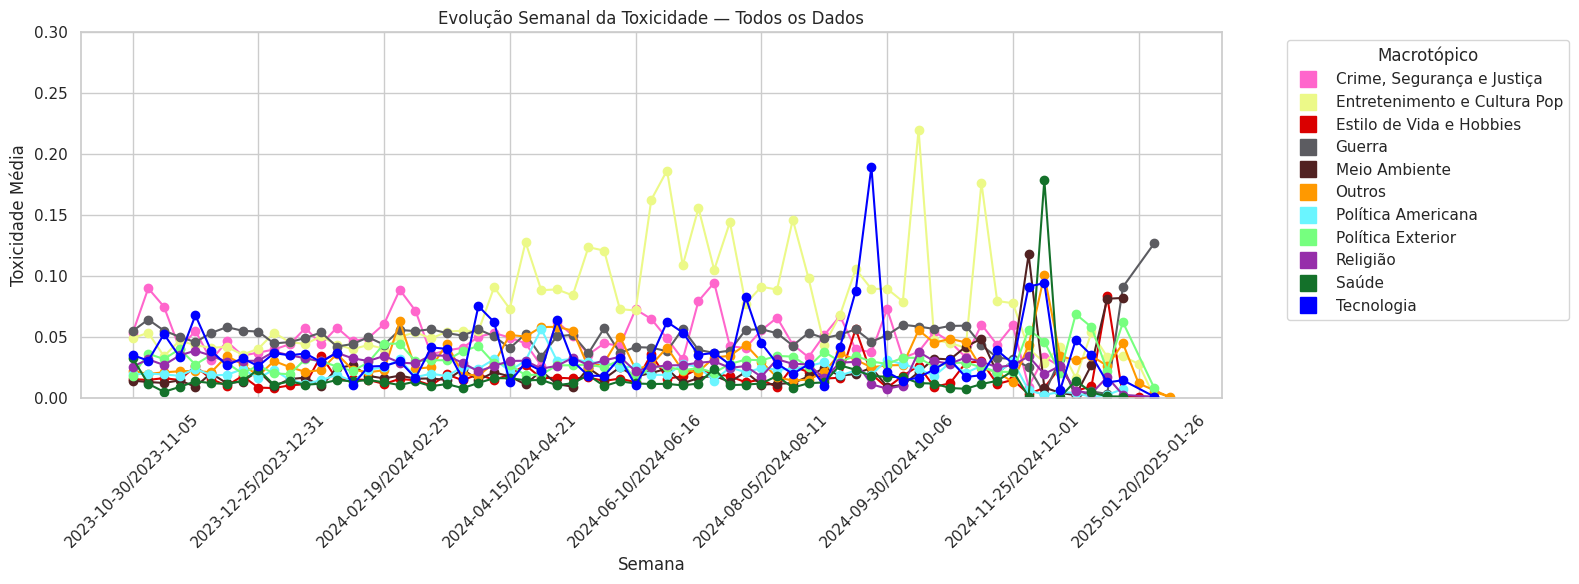

In [18]:
plot_weekly_toxicity_macros(df_exploded, "Todos os Dados")


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.lines import Line2D

def plot_weekly_toxic_percentage(df, group_col="macro_topic", threshold=0.4, title="Porcentagem Semanal de Textos Tóxicos"):

    df = df.copy()
    df["week"] = df["date"].dt.to_period("W").dt.start_time

    # marca toxicos
    df["is_toxic"] = (df["toxicity"] > threshold).astype(int)

    # agrupa
    weekly = (
        df.groupby([group_col, "week"])
        .agg(
            total=("is_toxic", "count"),
            tox_count=("is_toxic", "sum")
        )
        .reset_index()
    )

    weekly["tox_percent"] = 100 * weekly["tox_count"] / weekly["total"]

    # paleta padronizada de 7 cores
    palette = {
        "Política Americana":             "#6AF5FF",
        "Política Exterior":              "#76FF7F",
        "Crime, Segurança e Justiça":     "#FF66CC",
        "Meio Ambiente":                  "#522222",
        "Saúde":                          "#14712A",
        "Entretenimento e Cultura Pop":   "#ECF988",
        "Estilo de Vida e Hobbies":       "#DA0000",
        "Religião":                       "#962EAA",
        "Tecnologia":                     "#0000FF",
        "Guerra":                         "#5C5C61",
        "Outros":                         "#FF9900"
    }

    plt.figure(figsize=(16, 6))

    for group in weekly[group_col].unique():
        subset = weekly[weekly[group_col] == group]
        plt.plot(
            subset["week"],
            subset["tox_percent"],
            marker="o",
            label=group,
            color=palette.get(group, None)
        )

    plt.title(title)
    plt.ylabel("Porcentagem de Textos Tóxicos (%)")
    plt.xlabel("Semana")
    plt.ylim(0, weekly["tox_percent"].max() * 1.2)
    plt.xticks(rotation=45)

    # Limpa eixo X
    ax = plt.gca()
    step = max(1, len(ax.get_xticks()) // 15)
    ax.set_xticks(ax.get_xticks()[::step])

    plt.legend(title=group_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


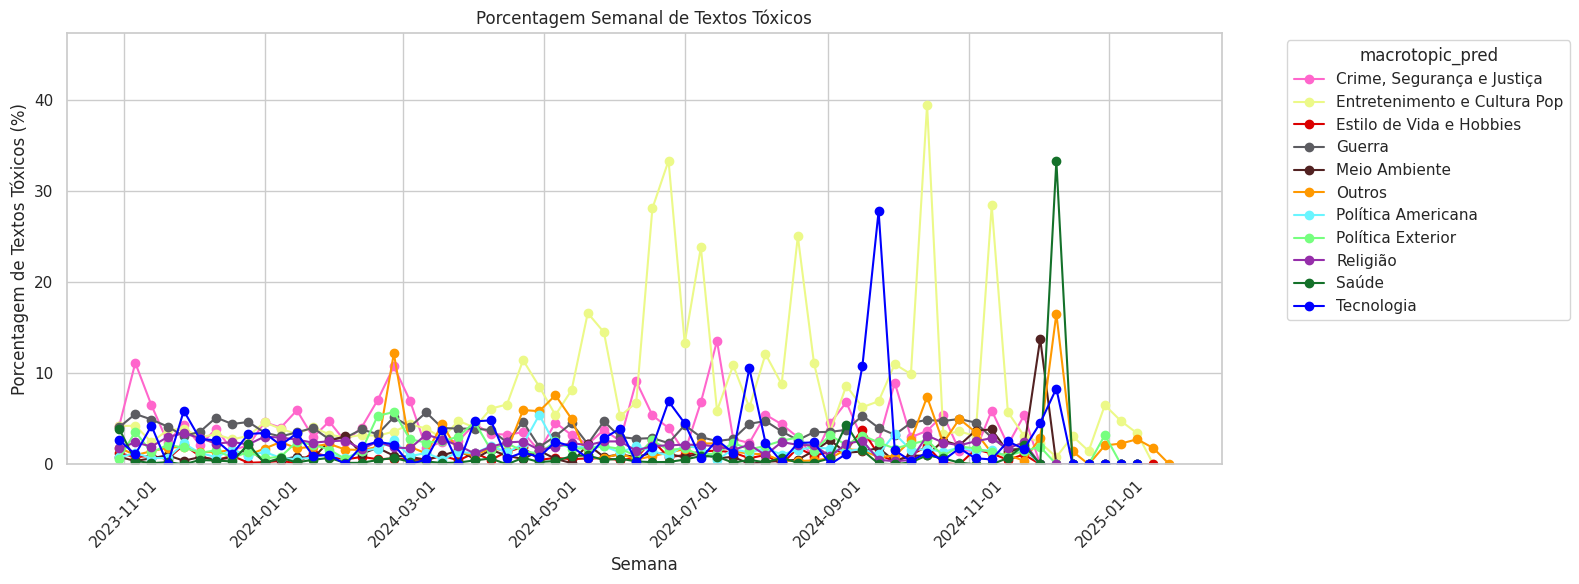

In [20]:
plot_weekly_toxic_percentage(df_exploded, group_col="macrotopic_pred")
